# Climate Change Prediction using Single-Country Gradient Boosting


## Import the library

In [1]:
import warnings

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import display
from scipy import stats
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")
np.random.seed(42)

MODEL_BACKEND = "histgradientboosting"

if False:
    try:
        from lightgbm import LGBMRegressor
        MODEL_BACKEND = "lightgbm"
    except ImportError:
        pass
else:        
    try:
        from xgboost import XGBRegressor
        MODEL_BACKEND = "xgboost"
    except ImportError:
        pass

# Comment this if the data visualisations doesn't work on your side
%matplotlib inline


In [2]:
print("Selected model backend:", MODEL_BACKEND)


Selected model backend: histgradientboosting


## Load the dataset

In [3]:
southeast_asian_countries = [
    "Brunei Darussalam",
    "Timor-Leste",
    "Cambodia",
    "Indonesia",
    "Lao PDR",
    "Malaysia",
    "Myanmar",
    "Philippines",
    "Singapore",
    "Thailand",
]

data_root = "data_effect_climate_change"

df_ghg = pd.read_excel(f"{data_root}/OWID_CB_TOTAL_GHG_WIDEF.ods")
df_temp = pd.read_csv(f"{data_root}/WB_CCKP_TAS_WIDEF.csv")
df_energy_consumption = pd.read_csv(
    f"{data_root}/OWID_CB_PRIMARY_ENERGY_CONSUMPTION_WIDEF.csv"
)
df_sustainable_energy_consumption = pd.read_csv(
    f"{data_root}/WB_SE4ALL_EG_FCON_RNEW_WIDEF.csv"
)
df_forest_area_percentage = pd.read_csv(
    f"{data_root}/WB_WDI_AG_LND_FRST_ZS_WIDEF.csv"
)
df_gdp = pd.read_csv(f"{data_root}/WB_WDI_NY_GDP_PCAP_KN_WIDEF.csv")


def get_data(country, df, min_year=1950):
    df = df.copy()
    df.columns = df.columns.astype(str)
    index = df[df["REF_AREA_LABEL"] == country].index[0]
    year_cols = sorted(
        [
            col
            for col in df.columns
            if col.isdigit() and int(col) >= min_year and int(col) <= 2100
        ],
        key=int,
    )
    data = pd.to_numeric(df.loc[index, year_cols], errors="coerce")
    data.index = pd.Index([int(year) for year in year_cols], name="year")
    return data.sort_index()


def get_country_series(country):
    return {
        "ghg_current": get_data(country, df_ghg).astype(float),
        "temperature": get_data(country, df_temp).astype(float),
        "energy_consumption": get_data(country, df_energy_consumption).astype(float),
        "sustainable_energy": get_data(
            country, df_sustainable_energy_consumption
        ).astype(float),
        "forest_area_pct": get_data(country, df_forest_area_percentage).astype(float),
        "gdp_per_capita": get_data(country, df_gdp).astype(float),
    }


## Build Country-Specific Modeling Data

Each country is modeled independently with lagged tabular features for gradient boosting.


In [4]:
def compute_optimal_lag_silent(target, variable, max_lag=5):
    best_lag = 0
    best_abs_rho = -1
    for lag in range(max_lag + 1):
        tmp = pd.DataFrame({"target": target, "var": variable.shift(lag)}).dropna()
        if len(tmp) < 3:
            continue
        rho, _ = stats.spearmanr(tmp["var"], tmp["target"])
        if pd.notna(rho) and abs(rho) > best_abs_rho:
            best_abs_rho = abs(rho)
            best_lag = lag
    return best_lag


def build_country_dataset(country, max_lag=5):
    series_map = get_country_series(country)
    ghg = series_map["ghg_current"]
    temp = series_map["temperature"]
    energy = series_map["energy_consumption"]
    sustainable = series_map["sustainable_energy"]
    forest = series_map["forest_area_pct"]
    gdp = series_map["gdp_per_capita"]

    lags = {
        "temperature": compute_optimal_lag_silent(ghg, temp, max_lag=max_lag),
        "energy_consumption": compute_optimal_lag_silent(ghg, energy, max_lag=max_lag),
        "sustainable_energy": compute_optimal_lag_silent(ghg, sustainable, max_lag=max_lag),
        "forest_area_pct": compute_optimal_lag_silent(ghg, forest, max_lag=max_lag),
        "gdp_per_capita": compute_optimal_lag_silent(ghg, gdp, max_lag=max_lag),
    }

    years = sorted(series_map["ghg_current"].index)
    panel = pd.DataFrame({"year": years, "country": country})
    panel["ghg_current"] = ghg.reindex(years).values
    panel["temperature"] = temp.shift(lags["temperature"]).reindex(years).values
    panel["energy_consumption"] = (
        energy.shift(lags["energy_consumption"]).reindex(years).values
    )
    panel["sustainable_energy"] = (
        sustainable.shift(lags["sustainable_energy"]).reindex(years).values
    )
    panel["forest_area_pct"] = forest.shift(lags["forest_area_pct"]).reindex(years).values
    panel["gdp_per_capita"] = gdp.shift(lags["gdp_per_capita"]).reindex(years).values

    panel["ghg_next_year"] = panel["ghg_current"].shift(-1)
    panel["ghg_lag1"] = panel["ghg_current"].shift(1)
    panel["ghg_lag2"] = panel["ghg_current"].shift(2)
    panel["ghg_lag3"] = panel["ghg_current"].shift(3)
    panel["ghg_roll3"] = panel["ghg_current"].shift(1).rolling(3).mean()
    panel["ghg_roll5"] = panel["ghg_current"].shift(1).rolling(5).mean()
    panel["ghg_diff1"] = panel["ghg_current"] - panel["ghg_lag1"]
    panel["ghg_diff2"] = panel["ghg_lag1"] - panel["ghg_lag2"]
    panel["year_index"] = panel["year"] - panel["year"].min()

    feature_cols = [
        "year_index",
        "ghg_current",
        "ghg_lag1",
        "ghg_lag2",
        "ghg_lag3",
        "ghg_roll3",
        "ghg_roll5",
        "ghg_diff1",
        "ghg_diff2",
        "temperature",
        "energy_consumption",
        "sustainable_energy",
        "forest_area_pct",
        "gdp_per_capita",
    ]

    model_df = panel.dropna(subset=feature_cols + ["ghg_next_year"]).copy()
    future_feature_df = panel.dropna(subset=feature_cols).copy()
    return model_df, future_feature_df, lags, feature_cols, series_map


def make_regressor(random_state=42):
    if MODEL_BACKEND == "lightgbm":
        return LGBMRegressor(
            objective="regression",
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            num_leaves=15,
            subsample=0.9,
            colsample_bytree=0.9,
            min_child_samples=3,
            reg_alpha=0.1,
            reg_lambda=0.2,
            random_state=random_state,
        )
    if MODEL_BACKEND == "xgboost":
        return XGBRegressor(
            objective="reg:squarederror",
            n_estimators=300,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.9,
            colsample_bytree=0.9,
            reg_alpha=0.1,
            reg_lambda=0.2,
            random_state=random_state,
        )
    return HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_depth=3,
        max_iter=300,
        l2_regularization=0.1,
        random_state=random_state,
    )


def fit_log_model(train_df, feature_cols):
    model = make_regressor(random_state=42)
    x_train = train_df[feature_cols]
    y_train = np.log1p(np.clip(train_df["ghg_next_year"].values.astype(float), a_min=0, a_max=None))
    model.fit(x_train, y_train)
    return model


def predict_from_log_model(model, x):
    pred_log = model.predict(x)
    pred = np.expm1(pred_log)
    return np.clip(pred, a_min=0, a_max=None)


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def rolling_backtest(country, model_df, feature_cols, min_train_size=18, max_splits=6):
    model_df = model_df.sort_values("year").reset_index(drop=True)
    available_splits = len(model_df) - min_train_size
    if available_splits < 3:
        return pd.DataFrame()

    n_splits = min(max_splits, available_splits)
    test_start = len(model_df) - n_splits
    rows = []

    for test_idx in range(test_start, len(model_df)):
        train_df = model_df.iloc[:test_idx].copy()
        test_df = model_df.iloc[[test_idx]].copy()
        model = fit_log_model(train_df, feature_cols)
        pred = float(predict_from_log_model(model, test_df[feature_cols])[0])
        actual = float(test_df["ghg_next_year"].iloc[0])
        naive_pred = float(test_df["ghg_current"].iloc[0])

        rows.append(
            {
                "country": country,
                "feature_year": int(test_df["year"].iloc[0]),
                "predict_for_year": int(test_df["year"].iloc[0] + 1),
                "actual_ghg": actual,
                "predicted_ghg": pred,
                "naive_predicted_ghg": naive_pred,
            }
        )

    return pd.DataFrame(rows)


def summarize_backtest(backtest_df):
    actual = backtest_df["actual_ghg"].values
    pred = backtest_df["predicted_ghg"].values
    naive = backtest_df["naive_predicted_ghg"].values

    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    r2 = r2_score(actual, pred) if len(backtest_df) > 1 else np.nan
    rmse_naive = np.sqrt(mean_squared_error(actual, naive))
    mae_naive = mean_absolute_error(actual, naive)
    r2_naive = r2_score(actual, naive) if len(backtest_df) > 1 else np.nan

    return {
        "backtest_years": int(len(backtest_df)),
        "mae": float(mae),
        "rmse": float(rmse),
        "r2": float(r2) if pd.notna(r2) else np.nan,
        "mape": float(mape(actual, pred)),
        "naive_mae": float(mae_naive),
        "naive_rmse": float(rmse_naive),
        "naive_r2": float(r2_naive) if pd.notna(r2_naive) else np.nan,
        "naive_mape": float(mape(actual, naive)),
        "rmse_gain_vs_naive": float(rmse_naive - rmse),
        "mae_gain_vs_naive": float(mae_naive - mae),
    }


def extrapolate_series(series, target_end_year, trend_window=5):
    series = series.dropna().astype(float).sort_index()
    if len(series) == 0:
        return series

    history = series.tail(min(trend_window, len(series)))
    if len(history) >= 2:
        slope, intercept = np.polyfit(history.index.astype(float), history.values.astype(float), 1)
    else:
        slope, intercept = 0.0, float(history.iloc[-1])

    extended = series.copy()
    last_year = int(series.index.max())
    for year in range(last_year + 1, int(target_end_year) + 1):
        extended.loc[year] = float(slope * year + intercept)
    return extended.sort_index()


def build_recursive_feature_row(feature_year, ghg_history, exogenous_future, lags, base_year):
    required_years = [feature_year, feature_year - 1, feature_year - 2, feature_year - 3]
    if any(year not in ghg_history.index for year in required_years):
        return None

    lag_values = [float(ghg_history.loc[feature_year - i]) for i in range(1, 6) if feature_year - i in ghg_history.index]
    if len(lag_values) < 5:
        return None

    row = {
        "year": feature_year,
        "year_index": feature_year - base_year,
        "ghg_current": float(ghg_history.loc[feature_year]),
        "ghg_lag1": float(ghg_history.loc[feature_year - 1]),
        "ghg_lag2": float(ghg_history.loc[feature_year - 2]),
        "ghg_lag3": float(ghg_history.loc[feature_year - 3]),
        "ghg_roll3": float(np.mean(lag_values[:3])),
        "ghg_roll5": float(np.mean(lag_values[:5])),
        "ghg_diff1": float(ghg_history.loc[feature_year] - ghg_history.loc[feature_year - 1]),
        "ghg_diff2": float(ghg_history.loc[feature_year - 1] - ghg_history.loc[feature_year - 2]),
    }

    for feature_name, series in exogenous_future.items():
        source_year = feature_year - lags[feature_name]
        if source_year not in series.index:
            return None
        row[feature_name] = float(series.loc[source_year])

    return row


def recursive_multi_year_forecast(
    country,
    final_model,
    series_map,
    lags,
    feature_cols,
    forecast_start_year,
    forecast_end_year,
):
    base_year = int(series_map["ghg_current"].dropna().index.min())
    ghg_history = series_map["ghg_current"].dropna().astype(float).sort_index().copy()
    exogenous_future = {
        key: extrapolate_series(series_map[key], forecast_end_year)
        for key in ["temperature", "energy_consumption", "sustainable_energy", "forest_area_pct", "gdp_per_capita"]
    }

    rows = []
    last_feature_year = int(ghg_history.index.max())

    for feature_year in range(last_feature_year, forecast_end_year):
        feature_row = build_recursive_feature_row(
            feature_year=feature_year,
            ghg_history=ghg_history,
            exogenous_future=exogenous_future,
            lags=lags,
            base_year=base_year,
        )
        if feature_row is None:
            break

        x_future = pd.DataFrame([feature_row])[feature_cols]
        pred = float(predict_from_log_model(final_model, x_future)[0])
        predict_for_year = feature_year + 1
        ghg_history.loc[predict_for_year] = pred

        if predict_for_year >= forecast_start_year:
            rows.append(
                {
                    "country": country,
                    "feature_year": feature_year,
                    "predict_for_year": predict_for_year,
                    "predicted_ghg_next_year": pred,
                    "forecast_assumption": "recursive_boosting_with_linear_trend_exogenous",
                    "model_backend": MODEL_BACKEND,
                }
            )

    return pd.DataFrame(rows)


## Train One Boosting Model Per Country with Rolling Validation


In [5]:
country_models = {}
country_evaluations = []
country_forecasts = []
country_multi_year_forecasts = []
country_backtest_predictions = []
country_lag_summary = []

forecast_start_year = 2026
forecast_end_year = 2031
min_train_size = 18
max_backtest_years = 6

for country in southeast_asian_countries:
    print(f"\n=== Training country model: {country} ===")

    model_df, future_feature_df, lags, feature_cols, series_map = build_country_dataset(
        country, max_lag=5
    )
    country_lag_summary.append({"country": country, **lags})

    model_df = model_df.sort_values("year").reset_index(drop=True)
    future_feature_df = future_feature_df.sort_values("year").reset_index(drop=True)

    if len(model_df) < min_train_size + 3:
        print(f"Skipped {country}: insufficient usable rows ({len(model_df)})")
        continue

    backtest_df = rolling_backtest(
        country=country,
        model_df=model_df,
        feature_cols=feature_cols,
        min_train_size=min_train_size,
        max_splits=max_backtest_years,
    )

    if len(backtest_df) == 0:
        print(f"Skipped {country}: rolling validation produced no folds")
        continue

    country_backtest_predictions.extend(backtest_df.to_dict("records"))
    summary = summarize_backtest(backtest_df)
    summary.update(
        {
            "country": country,
            "train_rows_full": int(len(model_df)),
            "latest_feature_year": int(future_feature_df["year"].iloc[-1]),
            "model_backend": MODEL_BACKEND,
            "target_transform": "log1p",
            "validation_strategy": "rolling_one_step_backtest",
        }
    )
    country_evaluations.append(summary)

    final_model = fit_log_model(model_df, feature_cols)

    latest_features = future_feature_df.tail(1)
    next_year_pred = float(predict_from_log_model(final_model, latest_features[feature_cols])[0])
    latest_feature_year = int(latest_features["year"].iloc[0])
    country_forecasts.append(
        {
            "country": country,
            "latest_feature_year": latest_feature_year,
            "predict_for_year": latest_feature_year + 1,
            "predicted_ghg_next_year": next_year_pred,
            "model_backend": MODEL_BACKEND,
        }
    )

    multi_year_df = recursive_multi_year_forecast(
        country=country,
        final_model=final_model,
        series_map=series_map,
        lags=lags,
        feature_cols=feature_cols,
        forecast_start_year=forecast_start_year,
        forecast_end_year=forecast_end_year,
    )
    if len(multi_year_df) > 0:
        country_multi_year_forecasts.extend(multi_year_df.to_dict("records"))

    country_models[country] = {
        "model": final_model,
        "feature_cols": feature_cols,
        "lags": lags,
    }
    print(
        f"Done {country}: rows={len(model_df)}, "
        f"backtest_years={summary['backtest_years']}, rmse={summary['rmse']:.3f}, "
        f"naive_rmse={summary['naive_rmse']:.3f}"
    )

evaluation_df = pd.DataFrame(country_evaluations).sort_values("rmse").reset_index(drop=True)
forecast_df = pd.DataFrame(country_forecasts).sort_values("country").reset_index(drop=True)
multi_year_forecast_df = (
    pd.DataFrame(country_multi_year_forecasts)
    .sort_values(["country", "predict_for_year"])
    .reset_index(drop=True)
)
backtest_predictions_df = (
    pd.DataFrame(country_backtest_predictions)
    .sort_values(["country", "predict_for_year"])
    .reset_index(drop=True)
)
lag_summary_df = pd.DataFrame(country_lag_summary).sort_values("country").reset_index(drop=True)

print(f"\nTotal trained country models: {len(country_models)}")
print(f"Evaluation rows: {len(evaluation_df)}")
print(f"Backtest prediction rows: {len(backtest_predictions_df)}")
print(f"Forecast rows: {len(forecast_df)}")
print(f"Multi-year forecast rows: {len(multi_year_forecast_df)}")



=== Training country model: Brunei Darussalam ===
Done Brunei Darussalam: rows=32, backtest_years=6, rmse=2.685, naive_rmse=0.810

=== Training country model: Timor-Leste ===
Skipped Timor-Leste: insufficient usable rows (15)

=== Training country model: Cambodia ===
Done Cambodia: rows=22, backtest_years=4, rmse=22.570, naive_rmse=3.837

=== Training country model: Indonesia ===
Done Indonesia: rows=31, backtest_years=6, rmse=223.782, naive_rmse=229.326

=== Training country model: Lao PDR ===
Done Lao PDR: rows=32, backtest_years=6, rmse=8.655, naive_rmse=2.917

=== Training country model: Malaysia ===
Done Malaysia: rows=27, backtest_years=6, rmse=59.693, naive_rmse=14.786

=== Training country model: Myanmar ===
Done Myanmar: rows=32, backtest_years=6, rmse=15.033, naive_rmse=11.617

=== Training country model: Philippines ===
Done Philippines: rows=27, backtest_years=6, rmse=44.405, naive_rmse=8.253

=== Training country model: Singapore ===
Done Singapore: rows=27, backtest_year

## Country-Level Evaluation

In [6]:
print("Rolling backtest summary")
display(evaluation_df)

print("Rolling backtest prediction details")
display(backtest_predictions_df)


Rolling backtest summary


,backtest_years,mae,rmse,r2,mape,naive_mae,naive_rmse,naive_r2,naive_mape,rmse_gain_vs_naive,mae_gain_vs_naive,country,train_rows_full,latest_feature_year,model_backend,target_transform,validation_strategy
0,6,2.656753,2.684932,-28.080298,15.666491,0.600333,0.810326,-1.648816,3.605174,-1.874606,-2.056420,Brunei Darussalam,32,2021,histgradientboosting,log1p,rolling_one_step_backtest
1,6,5.177237,5.412503,-15.395039,9.062027,1.879167,2.132386,-1.544767,3.326902,-3.280116,-3.298071,Singapore,27,2021,histgradientboosting,log1p,rolling_one_step_backtest
2,6,7.499247,8.654952,-3.960472,13.944991,2.113500,2.917199,0.436459,4.117467,-5.737754,-5.385747,Lao PDR,32,2021,histgradientboosting,log1p,rolling_one_step_backtest
3,6,9.899098,15.032631,-0.131545,4.381120,7.783833,11.617298,0.324210,3.631131,-3.415333,-2.115265,Myanmar,32,2021,histgradientboosting,log1p,rolling_one_step_backtest
4,4,22.160682,22.569556,-49.184482,25.520381,3.398500,3.837028,-0.450485,3.981451,-18.732529,-18.762182,Cambodia,22,2021,histgradientboosting,log1p,rolling_one_step_backtest
5,6,44.101395,44.404669,-99.184558,16.322876,6.762333,8.252549,-2.460347,2.521376,-36.152120,-37.339061,Philippines,27,2021,histgradientboosting,log1p,rolling_one_step_backtest
6,6,52.554171,54.813381,-17.942398,11.978549,7.692167,8.422846,0.552720,1.767591,-46.390534,-44.862005,Thailand,32,2021,histgradientboosting,log1p,rolling_one_step_backtest
7,6,58.735916,59.692731,-46.998746,14.383418,11.576333,14.786172,-1.945090,2.862000,-44.906559,-47.159583,Malaysia,27,2021,histgradientboosting,log1p,rolling_one_step_backtest
8,6,162.025833,223.782058,-1.199046,8.439939,172.291833,229.325800,-1.309349,9.444485,5.543741,10.266000,Indonesia,31,2021,histgradientboosting,log1p,rolling_one_step_backtest


Rolling backtest prediction details


,country,feature_year,predict_for_year,actual_ghg,predicted_ghg,naive_predicted_ghg
0,Brunei Darussalam,2016,2017,16.214,14.043520,14.445
1,Brunei Darussalam,2017,2018,16.356,14.118801,16.214
2,Brunei Darussalam,2018,2019,16.801,14.193498,16.356
3,Brunei Darussalam,2019,2020,17.372,14.276707,16.801
4,Brunei Darussalam,2020,2021,17.571,14.370947,17.372
5,Brunei Darussalam,2021,2022,17.095,14.465007,17.571
6,Cambodia,2018,2019,90.449,62.530664,86.927
7,Cambodia,2019,2020,86.401,63.760394,90.449
8,Cambodia,2020,2021,86.968,64.738505,86.401
9,Cambodia,2021,2022,81.511,65.656709,86.968


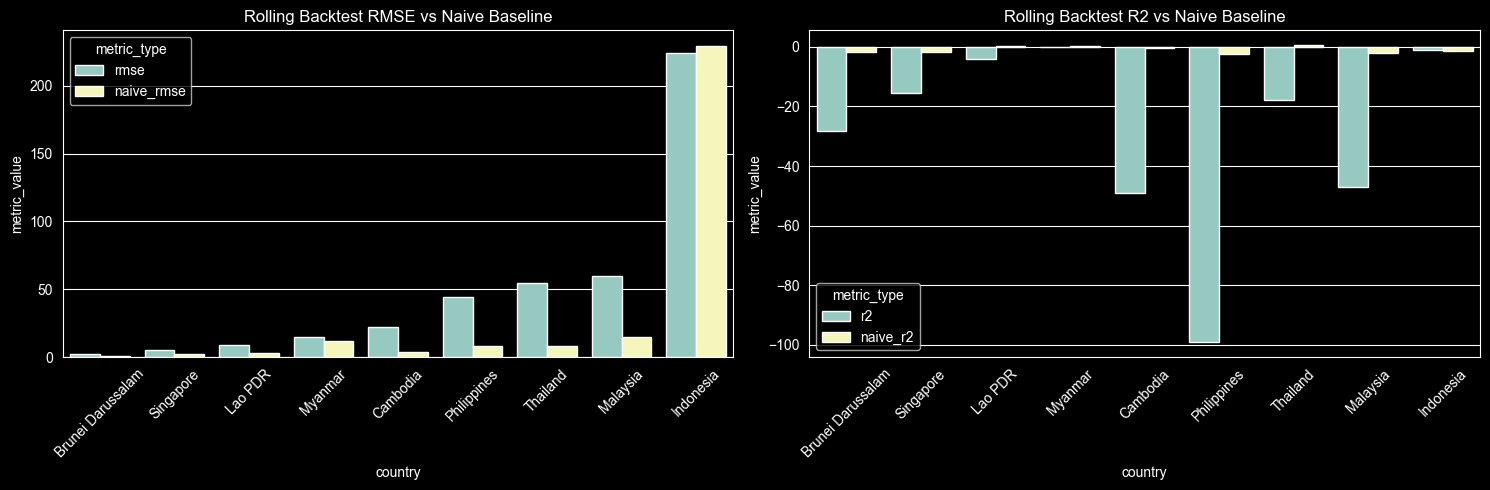

In [7]:
if len(evaluation_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    rmse_plot_df = evaluation_df.melt(
        id_vars="country",
        value_vars=["rmse", "naive_rmse"],
        var_name="metric_type",
        value_name="metric_value",
    )
    sns.barplot(data=rmse_plot_df, x="country", y="metric_value", hue="metric_type", ax=axes[0])
    axes[0].set_title("Rolling Backtest RMSE vs Naive Baseline")
    axes[0].tick_params(axis="x", rotation=45)

    r2_plot_df = evaluation_df.melt(
        id_vars="country",
        value_vars=["r2", "naive_r2"],
        var_name="metric_type",
        value_name="metric_value",
    )
    sns.barplot(data=r2_plot_df, x="country", y="metric_value", hue="metric_type", ax=axes[1])
    axes[1].set_title("Rolling Backtest R2 vs Naive Baseline")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()


## Country Forecasts

In [8]:
print("One-step next-year forecast")
display(forecast_df)

print("Recursive multi-year forecast for 2026-2031")
display(multi_year_forecast_df)


One-step next-year forecast


,country,latest_feature_year,predict_for_year,predicted_ghg_next_year,model_backend
0,Brunei Darussalam,2021,2022,14.541096,histgradientboosting
1,Cambodia,2021,2022,66.306351,histgradientboosting
2,Indonesia,2021,2022,1646.213762,histgradientboosting
3,Lao PDR,2021,2022,44.981698,histgradientboosting
4,Malaysia,2021,2022,355.504094,histgradientboosting
5,Myanmar,2021,2022,210.963081,histgradientboosting
6,Philippines,2021,2022,231.182013,histgradientboosting
7,Singapore,2021,2022,52.201743,histgradientboosting
8,Thailand,2021,2022,387.849417,histgradientboosting


Recursive multi-year forecast for 2026-2031


,country,feature_year,predict_for_year,predicted_ghg_next_year,forecast_assumption,model_backend
0,Brunei Darussalam,2025,2026,14.541096,recursive_boosting_with_linear_trend_exogenous,histgradientboosting
1,Brunei Darussalam,2026,2027,14.541096,recursive_boosting_with_linear_trend_exogenous,histgradientboosting
2,Brunei Darussalam,2027,2028,14.541096,recursive_boosting_with_linear_trend_exogenous,histgradientboosting
3,Brunei Darussalam,2028,2029,14.541096,recursive_boosting_with_linear_trend_exogenous,histgradientboosting
4,Brunei Darussalam,2029,2030,14.541096,recursive_boosting_with_linear_trend_exogenous,histgradientboosting
5,Brunei Darussalam,2030,2031,14.541096,recursive_boosting_with_linear_trend_exogenous,histgradientboosting
6,Cambodia,2025,2026,66.306351,recursive_boosting_with_linear_trend_exogenous,histgradientboosting
7,Cambodia,2026,2027,66.306351,recursive_boosting_with_linear_trend_exogenous,histgradientboosting
8,Cambodia,2027,2028,66.306351,recursive_boosting_with_linear_trend_exogenous,histgradientboosting
9,Cambodia,2028,2029,66.306351,recursive_boosting_with_linear_trend_exogenous,histgradientboosting


## Save Outputs

In [9]:
evaluation_df.to_csv("country_model_evaluation.csv", index=False)
backtest_predictions_df.to_csv("country_backtest_predictions.csv", index=False)
forecast_df.to_csv("country_ghg_forecast_next_year.csv", index=False)
multi_year_forecast_df.to_csv("country_ghg_forecast_2026_2031.csv", index=False)
lag_summary_df.to_csv("country_lag_summary.csv", index=False)

print("Saved: country_model_evaluation.csv")
print("Saved: country_backtest_predictions.csv")
print("Saved: country_ghg_forecast_next_year.csv")
print("Saved: country_ghg_forecast_2026_2031.csv")
print("Saved: country_lag_summary.csv")


Saved: country_model_evaluation.csv
Saved: country_backtest_predictions.csv
Saved: country_ghg_forecast_next_year.csv
Saved: country_ghg_forecast_2026_2031.csv
Saved: country_lag_summary.csv
